In [2]:
# import require libery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [4]:
# size 
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
# finding missing value
sentiment.isnull().sum()
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [8]:
# finding duplicate value
sentiment.duplicated().sum()
sentiment.duplicated().sum()


np.int64(0)

In [11]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [14]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

In [15]:
trades["date"] = trades["Timestamp IST"].dt.date

In [16]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [17]:
trades[["Timestamp IST","date"]].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [18]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
data = trades.merge(
    sentiment[["date","classification"]],
    on="date",
    how="left"
)

In [21]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [32]:
# Daily PnL per trader
daily_pnl = data.groupby(["Account","date"])["Closed PnL"].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [33]:
data["win"] = data["Closed PnL"] > 0

In [34]:
win_rate = data.groupby("Account")["win"].mean()

win_rate.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64

In [35]:
avg_trade_size = data.groupby("Account")["Size USD"].mean()

avg_trade_size.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64

In [38]:
trades_per_day = data.groupby("date").size()
trades_per_day.head()

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64

In [39]:
pd.crosstab(data["Side"], data["classification"])


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Side,,,,,
BUY,10935,17940,30270,24576,18969
SELL,10465,22052,31567,25727,18717


In [42]:
import seaborn as sns

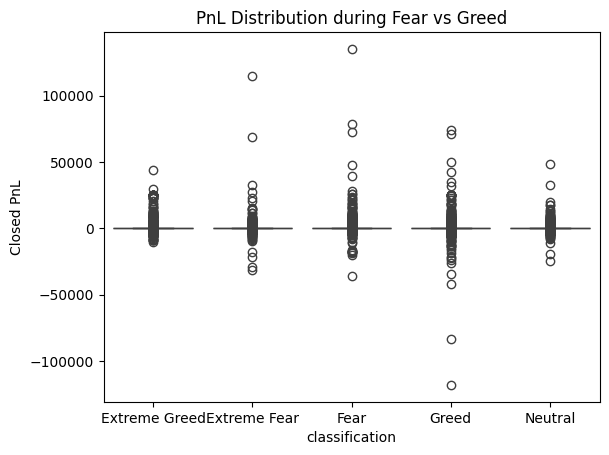

In [43]:
# checking pnl distribution across sentiment

sns.boxplot(x="classification", y="Closed PnL", data=data)

plt.title("PnL Distribution during Fear vs Greed")
plt.show()

In [44]:
data["win"] = data["Closed PnL"] > 0

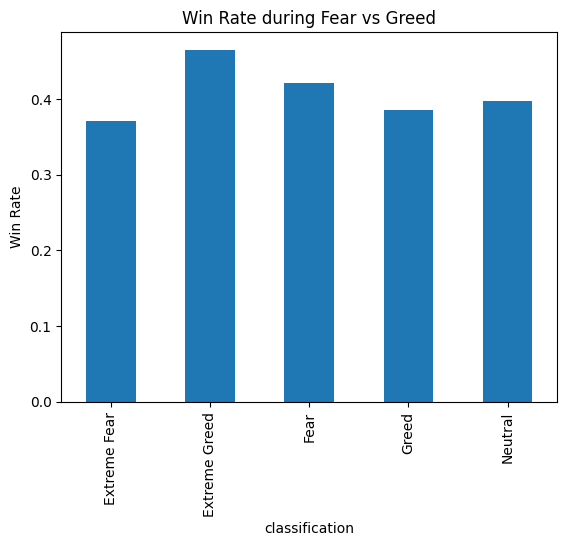

In [45]:
win_rate_sentiment = data.groupby("classification")["win"].mean()

win_rate_sentiment.plot(kind="bar")

plt.title("Win Rate during Fear vs Greed")
plt.ylabel("Win Rate")

plt.show()

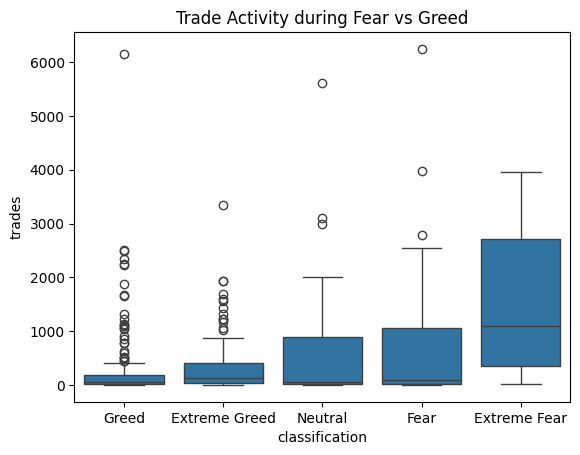

In [46]:
trades_by_day = data.groupby(["date","classification"]).size().reset_index(name="trades")

sns.boxplot(x="classification", y="trades", data=trades_by_day)

plt.title("Trade Activity during Fear vs Greed")

plt.show()

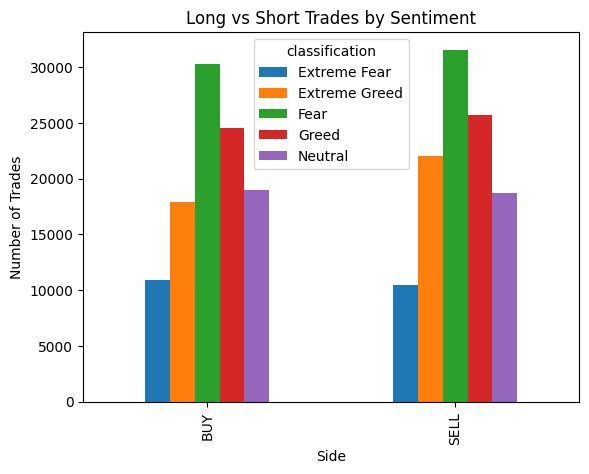

In [47]:
side_counts = pd.crosstab(data["Side"], data["classification"])

side_counts.plot(kind="bar")

plt.title("Long vs Short Trades by Sentiment")

plt.ylabel("Number of Trades")

plt.show()

In [48]:
trade_counts = data.groupby("Account").size()

In [50]:
threshold = trade_counts.median()

In [51]:
data["trader_segment"] = data["Account"].map(
    lambda x: "Frequent Trader" if trade_counts[x] > threshold else "Infrequent Trader"
)

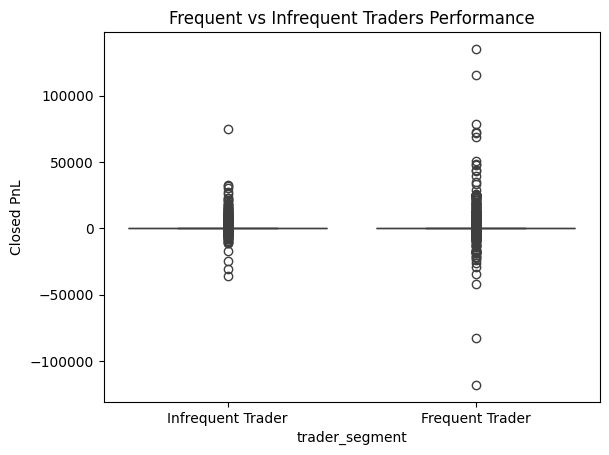

In [52]:
sns.boxplot(x="trader_segment", y="Closed PnL", data=data)

plt.title("Frequent vs Infrequent Traders Performance")

plt.show()

In [53]:
pnl_volatility = data.groupby("Account")["Closed PnL"].std()

pnl_volatility.describe()

count      32.000000
mean      856.056012
std       962.967993
min        68.234904
25%       246.968752
50%       550.480706
75%      1303.398442
max      4692.452329
Name: Closed PnL, dtype: float64

In [ ]:
___

## Part C — Actionable Output

### Strategy Idea 1 — Risk Reduction During Fear Markets

**Observation from analysis**

- Fear sentiment periods show lower trading activity  
- Traders appear more cautious during these periods  

### Strategy Rule

During Fear sentiment periods:

- Reduce position size  
- Avoid excessive trading  
- Focus on risk management strategies  

### Reasoning

Fear markets often indicate uncertainty and volatility, which increases downside risk.
Reducing trade size helps protect capital.

---

### Strategy Idea 2 — Momentum Trading During Greed Markets

**Observation from analysis**

- Greed sentiment periods show higher trade frequency  
- Traders tend to take more long positions  

### Strategy Rule

During Greed sentiment periods:

- Increase trading activity moderately  
- Focus on trend-following or momentum strategies  
- Monitor risk carefully


*1..simple predication model*

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [61]:
data["sentiment_num"] = data["classification"].map({
    "Fear":0,
    "Greed":1
})

In [62]:
features = data[["Size USD","sentiment_num"]]
target = data["win"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [58]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


*2️ Clustering Traders*

In [68]:
from sklearn.cluster import KMeans

cluster_features = data[["Size USD","Closed PnL"]]

kmeans = KMeans(n_clusters=3)

data["cluster"] = kmeans.fit_predict(cluster_features)

In [67]:
data.groupby("cluster")[["Size USD","Closed PnL"]].mean()

,Size USD,Closed PnL
cluster,,
0,4.123595e+03,43.741633
1,2.366092e+06,3603.404334
2,3.270160e+05,1216.681111
